In [33]:
from keras.utils import image_dataset_from_directory
from keras.applications.vgg16 import VGG16,preprocess_input,decode_predictions
from tensorflow.keras.models import Model,load_model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Rescaling,Resizing
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from sklearn.metrics import classification_report,confusion_matrix
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
from collections import Counter
import random

import numpy as np
import matplotlib.pyplot as plt
import prettypyplot as pplt
import seaborn as sns

import pickle
import cv2
import os
import shutil
from PIL import Image

In [2]:
train_ds=image_dataset_from_directory('../train_oversampling',seed=42,batch_size=16,image_size=(363,360))
class_names=train_ds.class_names
val_ds=image_dataset_from_directory('../val',seed=42,batch_size=16,image_size=(363,360),label_mode='int')
test_ds=image_dataset_from_directory('../test',seed=42,batch_size=16,image_size=(363,360),label_mode='int')

Found 18640 files belonging to 8 classes.
Found 2564 files belonging to 8 classes.
Found 2569 files belonging to 8 classes.


In [3]:
train_ds=train_ds.map(lambda x,y:(preprocess_input(x),y))
val_ds=val_ds.map(lambda x,y:(preprocess_input(x),y))
test_ds=test_ds.map(lambda x,y:(preprocess_input(x),y))

In [29]:
base_model=VGG16(weights='imagenet',include_top=False)
for layer in base_model.layers[-4:]:
    layer.trainable = True
for layer in base_model.layers[:-4]:
    layer.trainable = False
inputs=Input(shape=(363,360,3))
x=Resizing(224,224)(inputs)
x=Rescaling(1/255)(x)

x=base_model(x)
x=GlobalAveragePooling2D()(x)
x=Dense(1024,activation='relu')(x)
x=Dropout(rate=0.2)(x)
x=Dense(512,activation='relu')(x)
x=Dropout(rate=0.2)(x)
outputs=Dense(8,activation='softmax')(x)
model=Model(inputs=inputs,outputs=outputs)

In [24]:
for i, layer in enumerate(base_model.layers):
    print(f"{i+1:3}: {layer.name:40} — Trainable: {layer.trainable}")

  1: input_layer_4                            — Trainable: True
  2: block1_conv1                             — Trainable: True
  3: block1_conv2                             — Trainable: True
  4: block1_pool                              — Trainable: True
  5: block2_conv1                             — Trainable: True
  6: block2_conv2                             — Trainable: True
  7: block2_pool                              — Trainable: True
  8: block3_conv1                             — Trainable: True
  9: block3_conv2                             — Trainable: False
 10: block3_conv3                             — Trainable: False
 11: block3_pool                              — Trainable: False
 12: block4_conv1                             — Trainable: False
 13: block4_conv2                             — Trainable: False
 14: block4_conv3                             — Trainable: False
 15: block4_pool                              — Trainable: False
 16: block5_conv1                

In [30]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [31]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 363, 360, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │         4,104 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,768,904 (60.15 MB)

 Trainable params: 8,133,640 (31.03 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [27]:
early_stopping = EarlyStopping(
    monitor='val_loss',     # or 'val_accuracy'
    patience=5,             # wait 5 epochs before stopping
    mode='min',min_delta=0.001,
    restore_best_weights=True  # keep the best weights
)
reduceLR=ReduceLROnPlateau(monitor='val_loss',factor=0.1,min_lr=1e-6,patience=3,
                           min_delta=0.001,cooldown=4)

In [28]:
history_model=model.fit(train_ds,validation_data=val_ds,epochs=100,callbacks=[early_stopping,reduceLR])

Epoch 1/100
1165/1165 ━━━━━━━━━━━━━━━━━━━━ 144s 112ms/step - accuracy: 0.4033 - loss: 1.4886 - val_accuracy: 0.8931 - val_loss: 0.3540 - learning_rate: 0.0010
Epoch 2/100
1165/1165 ━━━━━━━━━━━━━━━━━━━━ 130s 111ms/step - accuracy: 0.9098 - loss: 0.2695 - val_accuracy: 0.9512 - val_loss: 0.1705 - learning_rate: 0.0010
Epoch 3/100
1165/1165 ━━━━━━━━━━━━━━━━━━━━ 130s 111ms/step - accuracy: 0.9370 - loss: 0.1877 - val_accuracy: 0.9637 - val_loss: 0.1165 - learning_rate: 0.0010
Epoch 4/100
1165/1165 ━━━━━━━━━━━━━━━━━━━━ 130s 111ms/step - accuracy: 0.9521 - loss: 0.1486 - val_accuracy: 0.9645 - val_loss: 0.1272 - learning_rate: 0.0010
Epoch 5/100
1165/1165 ━━━━━━━━━━━━━━━━━━━━ 129s 111ms/step - accuracy: 0.9626 - loss: 0.1144 - val_accuracy: 0.9598 - val_loss: 0.1386 - learning_rate: 0.0010
Epoch 6/100
1165/1165 ━━━━━━━━━━━━━━━━━━━━ 129s 111ms/step - accuracy: 0.9654 - loss: 0.1116 - val_accuracy: 0.9680 - val_loss: 0.0984 - learning_rate: 0.0010
Epoch 7/100
1165/1165 ━━━━━━━━━━━━━━━━━━━━ 129

In [ ]:
model=load_model('vgg16_model_fine_tuning_firstLayers.h5')
with open('training_history_vgg_fine_tuning_firstLayers.pkl', 'rb') as f:
    data=pickle.load(f)

In [11]:
print(data.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])


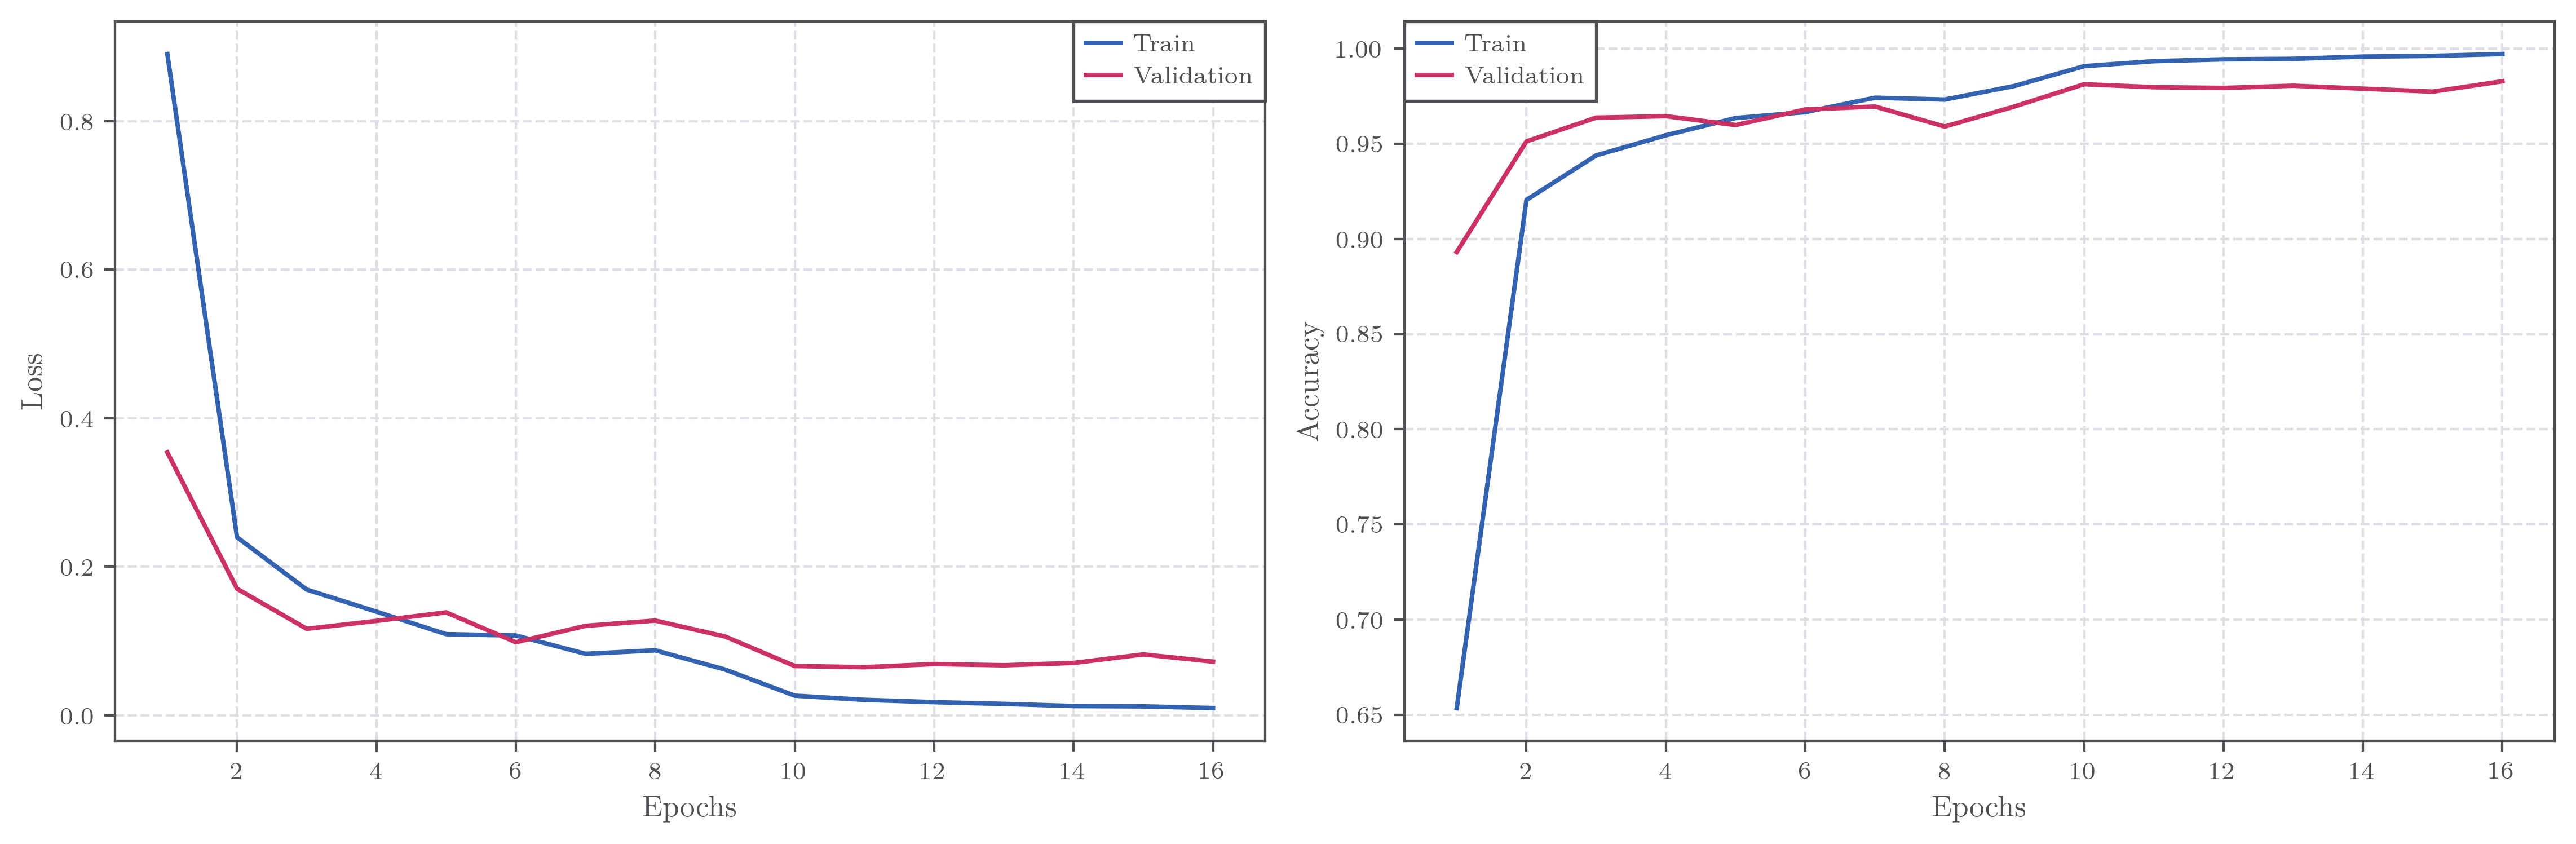

In [15]:
# loss=history_model.history['loss']
# val_loss=history_model.history['val_loss']
# accuracy=history_model.history['accuracy']
# val_accuracy=history_model.history['val_accuracy']
pplt.use_style()
loss=data['loss']
val_loss=data['val_loss']
accuracy=data['accuracy']
val_accuracy=data['val_accuracy']
plt.figure(figsize=(12,4))
plt.subplot(121)
plt.plot(np.arange(len(loss))+1,loss,label='Train')
plt.plot(np.arange(len(val_loss))+1,val_loss,label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend();
plt.subplot(122)
plt.plot(np.arange(len(accuracy))+1,accuracy,label='Train')
plt.plot(np.arange(len(val_accuracy))+1,val_accuracy,label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
pplt.savefig('loss_acc_vgg16.pdf');

In [16]:
def get_predictions_and_labels(dataset):
    true_labels = []
    pred_labels = []

    for images, labels in dataset:

        preds = model.predict(images, verbose=0)  # Get the model's predictions
        pred_labels.extend(np.argmax(preds, axis=-1))  # Get the predicted labels (argmax)

        true_labels.extend(labels.numpy())  # Get the true labels

    return np.array(true_labels), np.array(pred_labels)

y_true, y_pred = get_predictions_and_labels(test_ds)

In [21]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

    basophil       0.99      0.98      0.99       183
  eosinophil       1.00      1.00      1.00       468
erythroblast       0.99      0.97      0.98       233
          ig       0.97      0.95      0.96       435
  lymphocyte       0.97      0.99      0.98       183
    monocyte       0.96      0.97      0.97       214
  neutrophil       0.97      0.98      0.98       500
    platelet       1.00      0.99      1.00       353

    accuracy                           0.98      2569
   macro avg       0.98      0.98      0.98      2569
weighted avg       0.98      0.98      0.98      2569



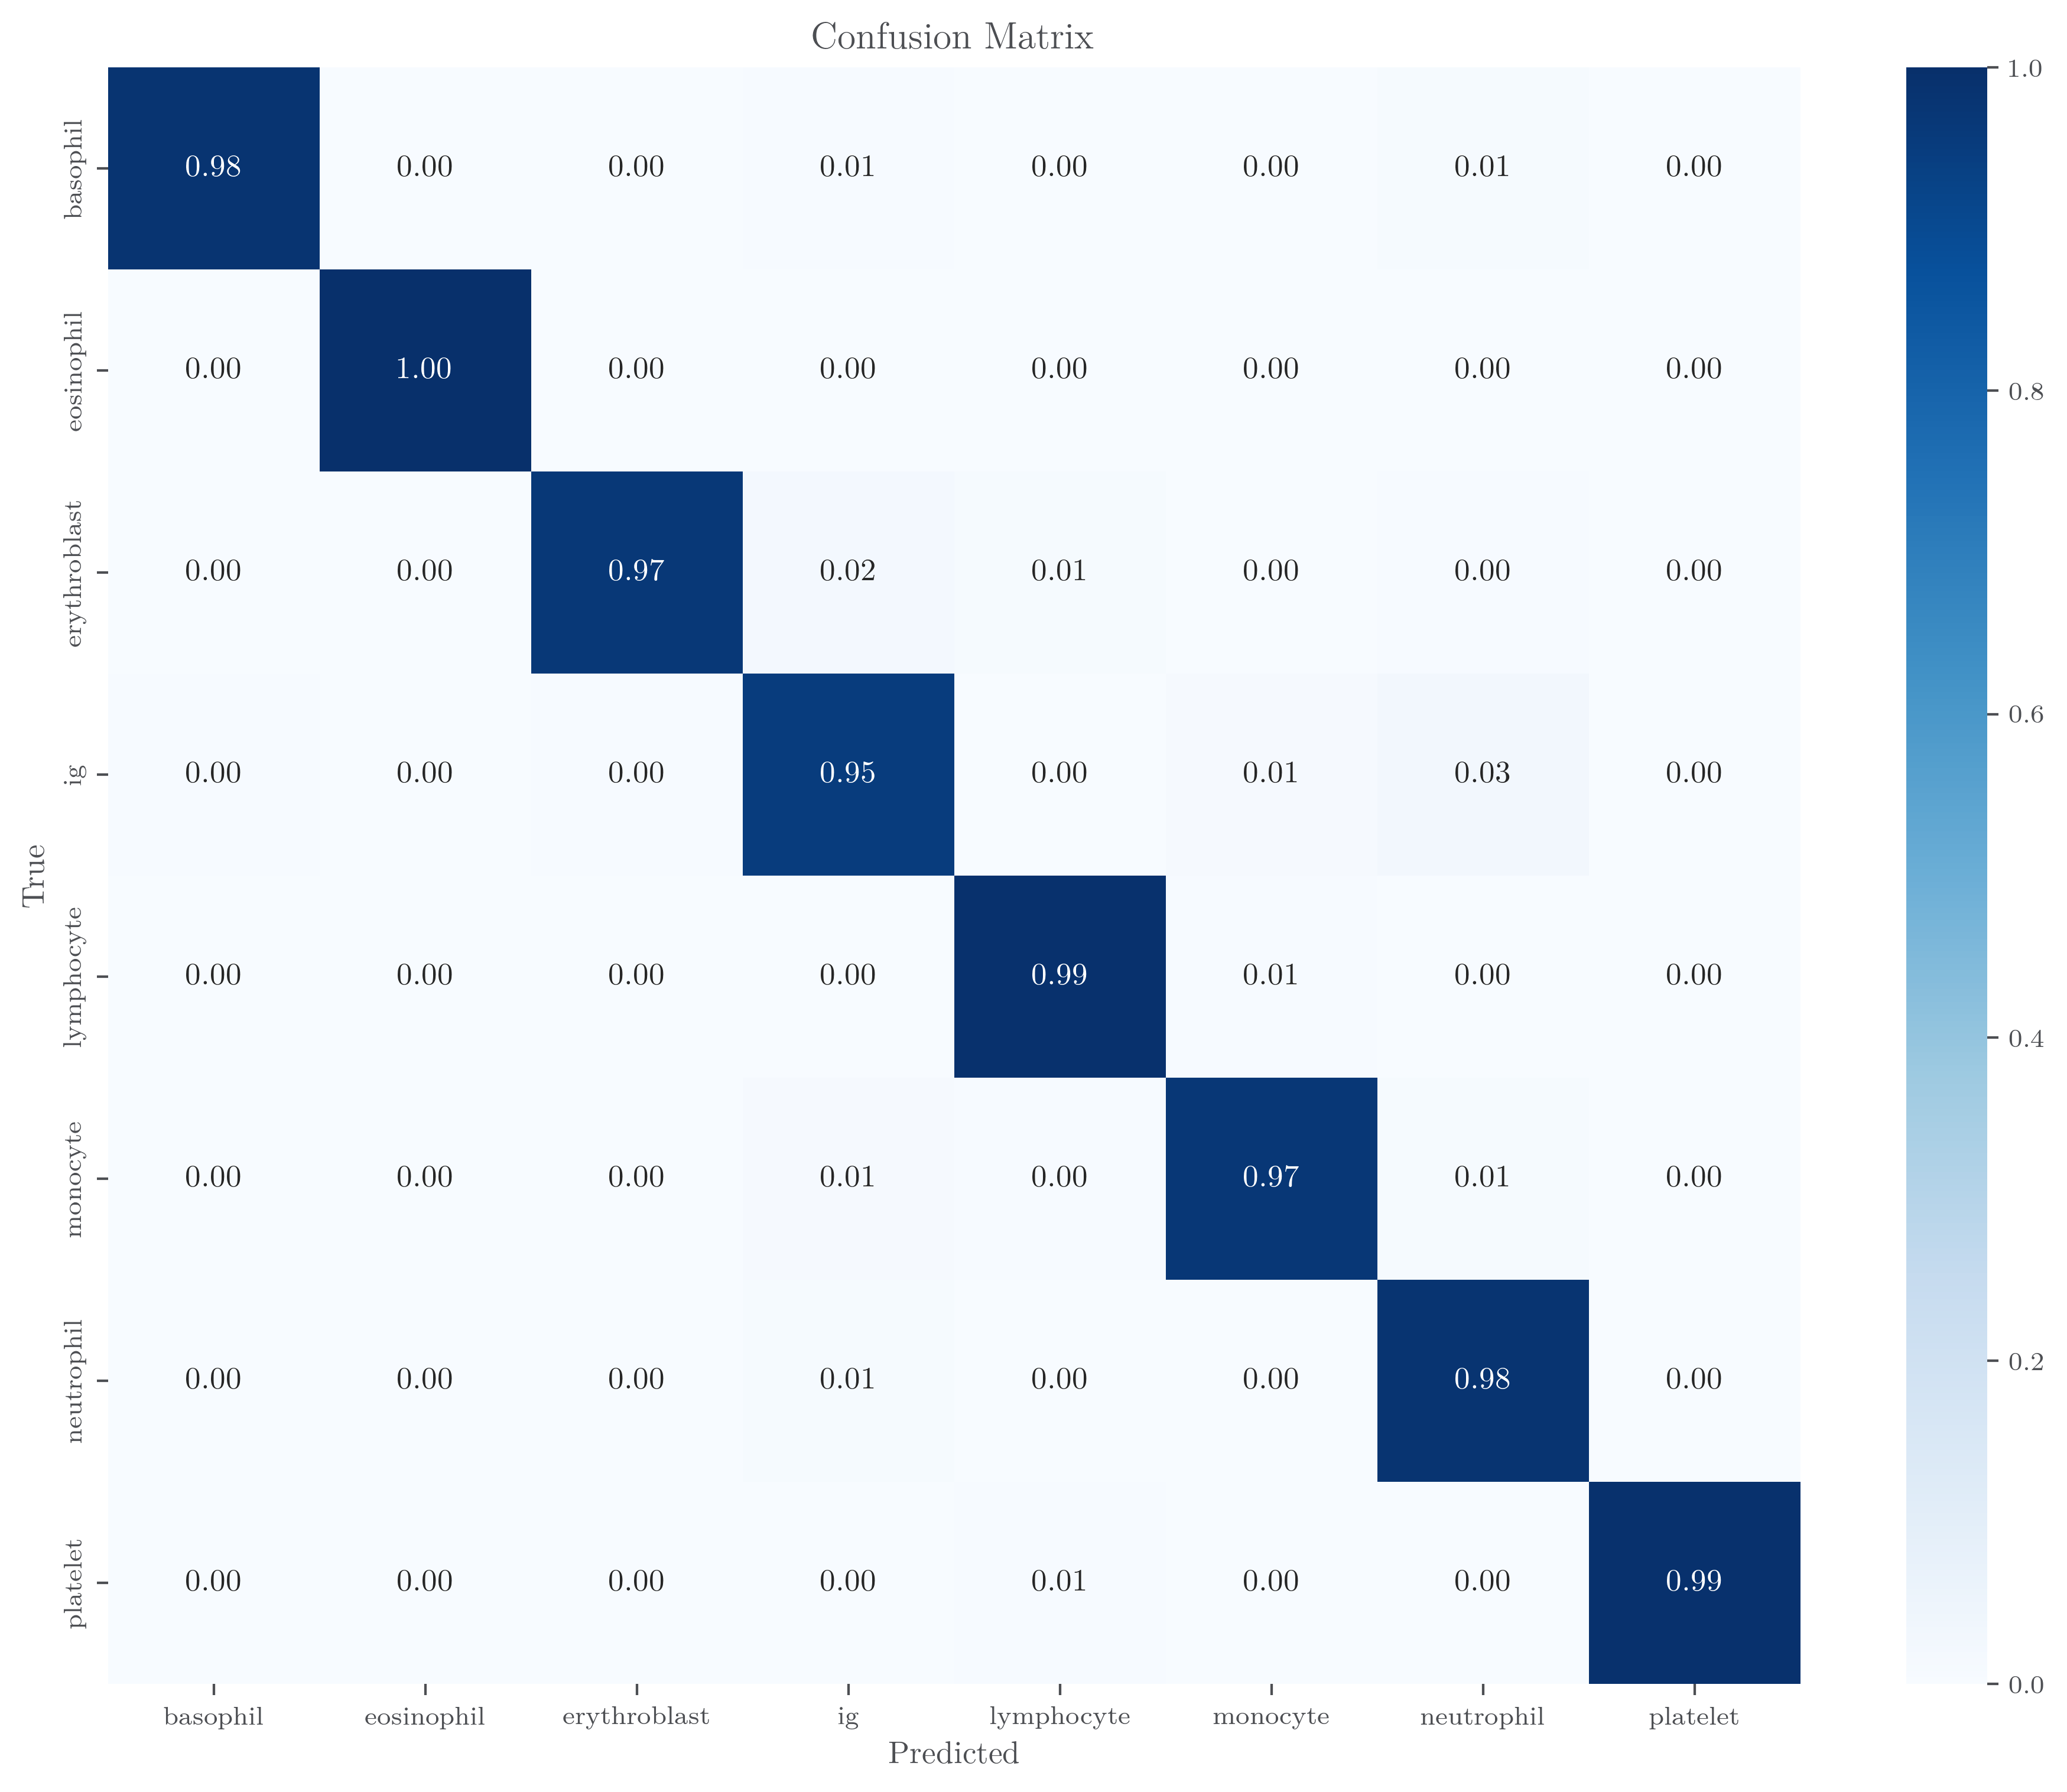

In [18]:
cm = confusion_matrix(y_true, y_pred,normalize='true')
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, xticklabels=class_names, yticklabels=class_names, fmt='.2f', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
pplt.savefig('cm_vgg16.pdf')
plt.show()

In [38]:
import pickle

with open('training_history_vgg_fine_tuning_firstLayers.pkl', 'wb') as f:
    pickle.dump(history_model.history, f)

In [37]:
model.save('vgg16_model_fine_tuning_firstLayers.h5')

In [44]:
img_path='../test/basophil/BA_580.jpg'
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_batch = np.expand_dims(img_array, axis=0)
img_preprocessed = preprocess_input(img_batch)

In [40]:
# Target last conv layer (you can change this depending on your model)
last_conv_layer_name = 'block5_conv3'

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Create a model that maps the input image to the activations
    grad_model = tf.keras.models.Model(
        [model.inputs], 
        [base_model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Record operations for automatic differentiation
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    # Gradient of the predicted class with respect to output of conv layer
    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads[0], axis=(0, 1))  # [channels]

    conv_outputs = conv_outputs[0]  # [height, width, channels]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalize
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

In [45]:
heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name='block5_conv3')

# Display it over original image
def display_gradcam(img_path, heatmap, alpha=0.4):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))  # model resizes to 224x224
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)

    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed = cv2.addWeighted(img, 1 - alpha, heatmap_color, alpha, 0)

    # Show
    plt.imshow(cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title('Grad-CAM')
    plt.show()

display_gradcam(img_path, heatmap)

ValueError: Input 0 of layer "functional_8" is incompatible with the layer: expected shape=(None, 363, 360, 3), found shape=(224, 224, 3)